# 03 — Infraestrutura Digital e Gap Bancário

**Objetivo**: avaliar conectividade, infraestrutura digital e concorrência física dos bancos tradicionais.

**Inputs**: `data/processed/trusted_municipios_eda.parquet`.

**Outputs**: figuras de infraestrutura, gap bancário e matriz de quadrantes.

In [1]:
# Imports
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.utils.eda import (
    plot_distribution,
    save_figure,
    save_json,
)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Leitura
df = pd.read_parquet(PROCESSED_DATA_DIR / "trusted_municipios_eda.parquet")
logger.info("Linhas: %d, Colunas: %d", df.shape[0], df.shape[1])

2026-09-03 12:13:22,178 - INFO - Linhas: 5570, Colunas: 32


## 1. Municípios sem agência bancária

In [3]:
sem_agencia = df["flag_sem_agencia"].sum()
logger.info(
    "Municípios sem agência: %d (%.2f%%)",
    sem_agencia,
    sem_agencia / len(df) * 100,
)

2026-09-03 12:13:22,516 - INFO - Municípios sem agência: 2656 (47.68%)


## 2. Distribuição de infraestrutura digital e gap bancário

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:13:24,272 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_dist_banda_larga.png


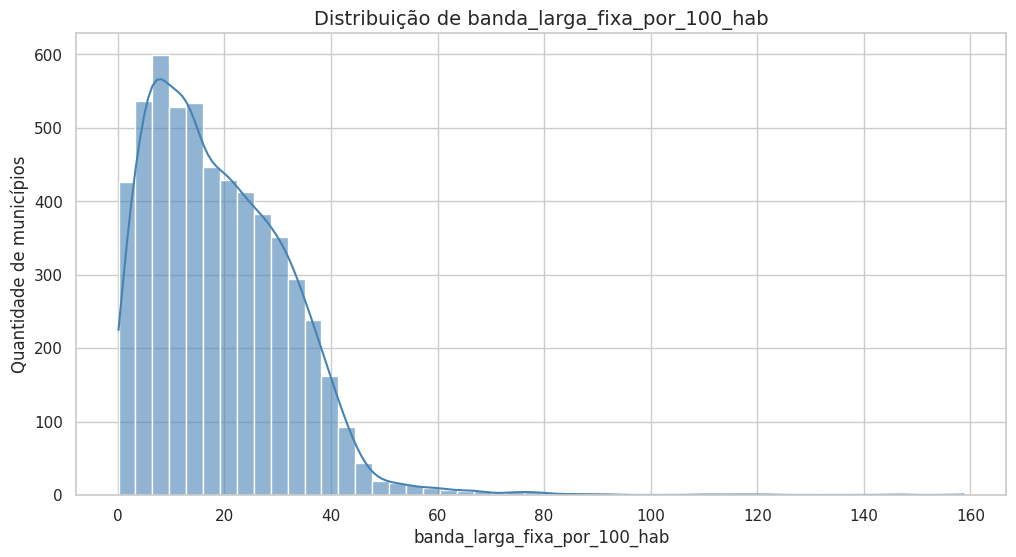

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:13:26,397 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_dist_agencias.png


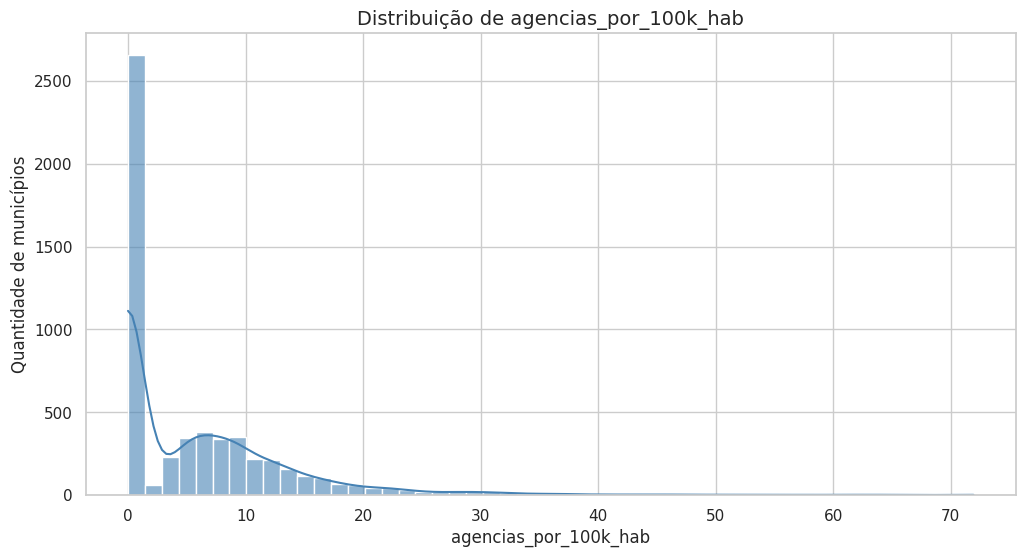

In [4]:
plot_distribution(
    df, "banda_larga_fixa_por_100_hab", filename="03_dist_banda_larga.png"
)
plt.show()

plot_distribution(
    df, "agencias_por_100k_hab", filename="03_dist_agencias.png"
)
plt.show()

## 3. Boxplots por região

2026-09-03 12:13:28,859 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_boxplot_banda_larga_fixa_por_100_hab_regiao.png


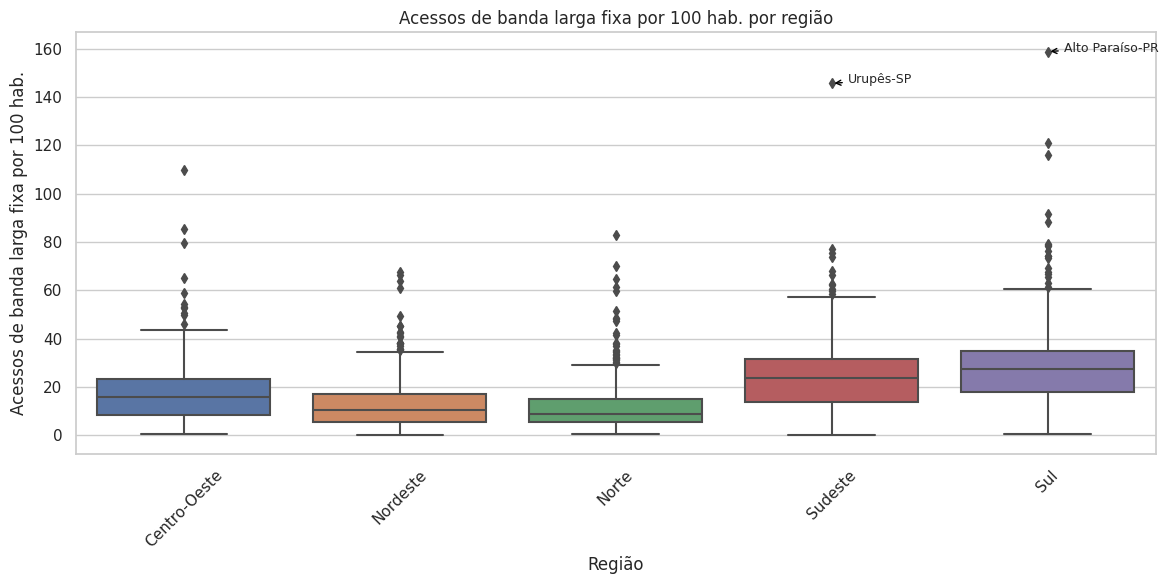

2026-09-03 12:13:31,190 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_boxplot_agencias_por_100k_hab_regiao.png


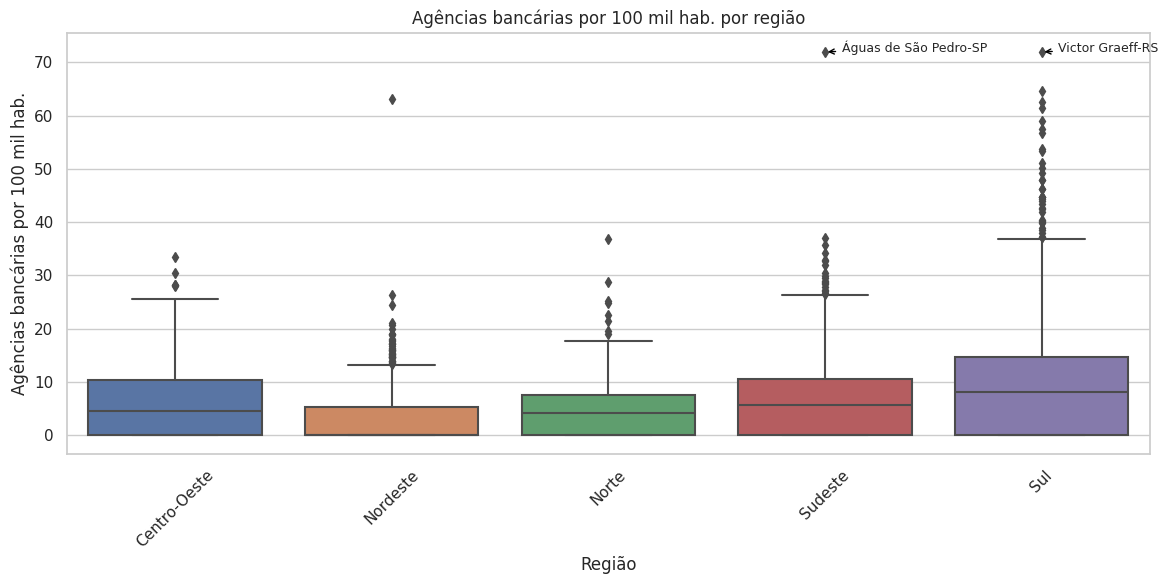

2026-09-03 12:13:33,189 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_boxplot_depositos_per_capita_regiao.png


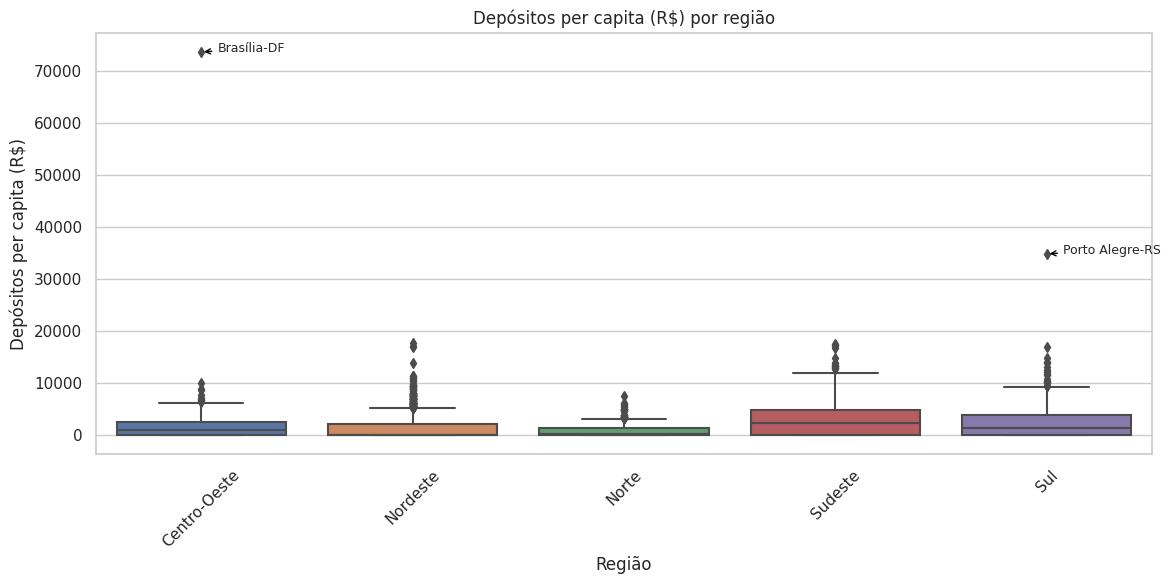

In [5]:
# Boxplots de infraestrutura por região
# Anotamos nos fliers o nome dos municípios outliers mais extremos de cada variável
# (fliers solitários, bem fora da caixa).
for col in ["banda_larga_fixa_por_100_hab", "agencias_por_100k_hab", "depositos_per_capita"]:
    if col == "banda_larga_fixa_por_100_hab":
        ylabel = "Acessos de banda larga fixa por 100 hab."
    elif col == "agencias_por_100k_hab":
        ylabel = "Agências bancárias por 100 mil hab."
    else:
        ylabel = "Depósitos per capita (R$)"

    fig, ax = plt.subplots(figsize=(12, 6))
    order = sorted(df["nome_regiao"].dropna().unique())
    sns.boxplot(data=df, x="nome_regiao", y=col, ax=ax, order=order)
    ax.set_title(f"{ylabel} por região")
    ax.set_xlabel("Região")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)

    # Nomear os 2 outliers mais extremos (regra do IQR, apenas fliers superiores)
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[df[col] > q3 + 1.5 * iqr].nlargest(2, col)
    for _, row in outliers.iterrows():
        ax.annotate(
            f"{row['nome_municipio']}-{row['sigla_uf']}",
            xy=(order.index(row["nome_regiao"]), row[col]),
            xytext=(12, 0),
            textcoords="offset points",
            fontsize=9,
            arrowprops=dict(arrowstyle="->", color="black"),
        )

    plt.tight_layout()
    save_figure(fig, f"03_boxplot_{col}_regiao.png")
    plt.show()


## 4. Correspondentes bancários por tipo (presença física da V3)

O pilar D da V3 do IPB não olha só agências: inclui correspondentes bancários por tipo (posto, filial, sede, agência). Aqui examinamos a composição da rede de correspondentes por região a partir da base bruta do BCB (posição 30/08/2026). A conclusão central: o tipo **Sede** (estabelecimento-sede do correspondente no cadastro do BCB) domina a base em todas as regiões, com Filial em segundo plano — ou seja, a presença física no interior é majoritariamente de correspondentes, não de agências. Como cada tipo tem capacidade de atendimento distinta, isso motivou a ponderação por tipo (posto 1,0 / filial 0,7 / sede 0,4 / agência 1,0) adotada no pilar D da V3.

2026-09-03 12:13:34,996 - INFO - Total de correspondentes: 216873


2026-09-03 12:13:35,078 - INFO - Composição geral por tipo (%):
Tipo
Sede       81.1
Filial     15.4
Posto       3.5
Agência     0.0
Name: proportion, dtype: float64


Tipo,Agência,Filial,Posto,Sede
nome_regiao,,,,
Centro-Oeste,1,2922,921,15919
Nordeste,0,6581,2266,45859
Norte,5,2006,462,10360
Sudeste,11,13898,3166,67493
Sul,4,8015,695,36287


2026-09-03 12:13:36,416 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_correspondentes_tipo_regiao.png


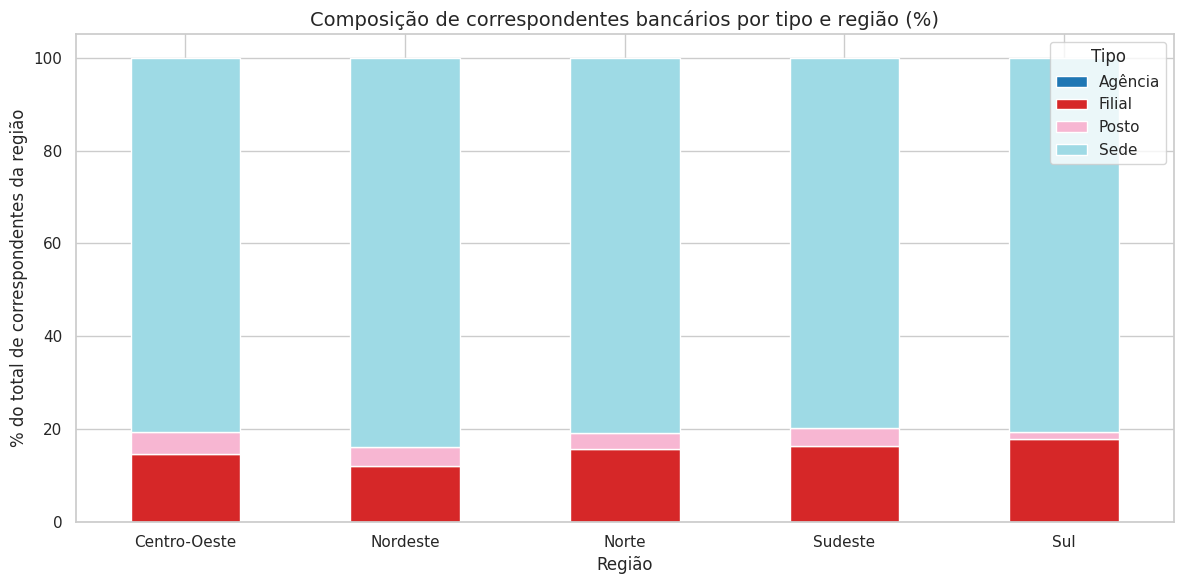

In [6]:
# Composição de correspondentes por tipo e região
# Fonte: raw_bcb_correspondentes (API OData do BCB, cache idempotente local).
df_corr = pd.read_parquet(RAW_DATA_DIR / "bcb_correspondentes" / "bcb_correspondentes.parquet")
df_corr_regiao = df_corr.merge(
    df[["id_municipio", "nome_regiao"]], on="id_municipio", how="left"
)

corr_tipo_regiao = (
    df_corr_regiao.groupby(["nome_regiao", "Tipo"]).size().unstack(fill_value=0)
)
corr_tipo_regiao_pct = corr_tipo_regiao.div(
    corr_tipo_regiao.sum(axis=1), axis=0
) * 100

logger.info("Total de correspondentes: %d", len(df_corr))
logger.info(
    "Composição geral por tipo (%%):\n%s",
    (df_corr["Tipo"].value_counts(normalize=True) * 100).round(1),
)
display(corr_tipo_regiao)

fig, ax = plt.subplots(figsize=(12, 6))
corr_tipo_regiao_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title(
    "Composição de correspondentes bancários por tipo e região (%)", fontsize=14
)
ax.set_xlabel("Região", fontsize=12)
ax.set_ylabel("% do total de correspondentes da região", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Tipo", loc="upper right")
plt.tight_layout()
save_figure(fig, "03_correspondentes_tipo_regiao.png")
plt.show()

## 5. Quadrantes: infraestrutura digital × gap bancário

Primeiro os quadrantes originais, usando apenas agências bancárias como proxy de presença física. Na subseção seguinte os recalculamos com a **presença combinada** da V3 (agências + correspondentes ponderados por 100k hab.) para medir quantos "maduros saturados" permanecem saturados quando lotéricas e correspondentes entram na conta.

In [7]:
mediana_banda = df["banda_larga_fixa_por_100_hab"].median()
mediana_agencias = df["agencias_por_100k_hab"].fillna(0).median()

df["quadrante"] = "desconectado"
df.loc[
    (df["banda_larga_fixa_por_100_hab"] >= mediana_banda)
    & (df["agencias_por_100k_hab"].fillna(0) < mediana_agencias),
    "quadrante",
] = "alto_potencial"
df.loc[
    (df["banda_larga_fixa_por_100_hab"] >= mediana_banda)
    & (df["agencias_por_100k_hab"].fillna(0) >= mediana_agencias),
    "quadrante",
] = "maduro_saturado"
df.loc[
    (df["banda_larga_fixa_por_100_hab"] < mediana_banda)
    & (df["agencias_por_100k_hab"].fillna(0) >= mediana_agencias),
    "quadrante",
] = "bancarizado_sem_infra"

logger.info("Distribuição dos quadrantes:\n%s", df["quadrante"].value_counts())

2026-09-03 12:13:37,117 - INFO - Distribuição dos quadrantes:
quadrante
maduro_saturado          1735
desconectado             1735
bancarizado_sem_infra    1050
alto_potencial           1050
Name: count, dtype: int64


2026-09-03 12:13:39,371 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_quadrantes_infra_gap.png


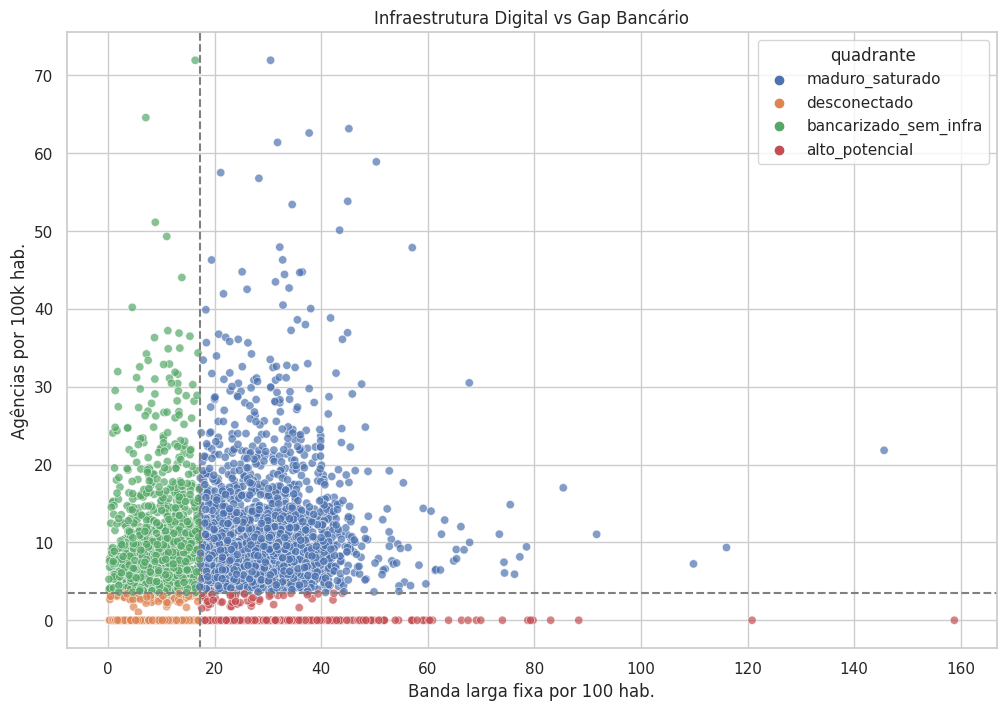

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="banda_larga_fixa_por_100_hab",
    y="agencias_por_100k_hab",
    hue="quadrante",
    alpha=0.7,
    ax=ax,
)
ax.axvline(mediana_banda, color="gray", linestyle="--")
ax.axhline(mediana_agencias, color="gray", linestyle="--")
ax.set_title("Infraestrutura Digital vs Gap Bancário")
ax.set_xlabel("Banda larga fixa por 100 hab.")
ax.set_ylabel("Agências por 100k hab.")
save_figure(fig, "03_quadrantes_infra_gap.png")
plt.show()

### Quadrantes revisados: presença combinada (agências + correspondentes ponderados)

Recalculamos os quadrantes trocando agências pela presença combinada da V3 (`agencias_por_100k_hab + correspondentes_ponderados_por_100k_hab`). O cruzamento abaixo compara as classificações antiga e nova: a pergunta é quantos municípios "maduros saturados" (banda larga alta + muitas agências) permanecem saturados quando lotéricas e correspondentes entram na conta — e quantos municípios aparentemente desatendidos (alto potencial) deixam de sê-lo porque na prática têm rede de correspondentes densa.

2026-09-03 12:13:40,868 - INFO - Quadrantes com presença combinada:
quadrante_combinado
desconectado             1552
maduro_saturado          1552
alto_potencial           1233
bancarizado_sem_infra    1233
Name: count, dtype: int64


quadrante_combinado,alto_potencial,bancarizado_sem_infra,desconectado,maduro_saturado
quadrante,,,,
alto_potencial,513,0,0,537
bancarizado_sem_infra,0,430,620,0
desconectado,0,803,932,0
maduro_saturado,720,0,0,1015


2026-09-03 12:13:40,932 - INFO - Maduros saturados (só agências): 1735; permanecem saturados com presença combinada: 1015 (58.5%)


2026-09-03 12:13:43,192 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_quadrantes_presenca_combinada.png


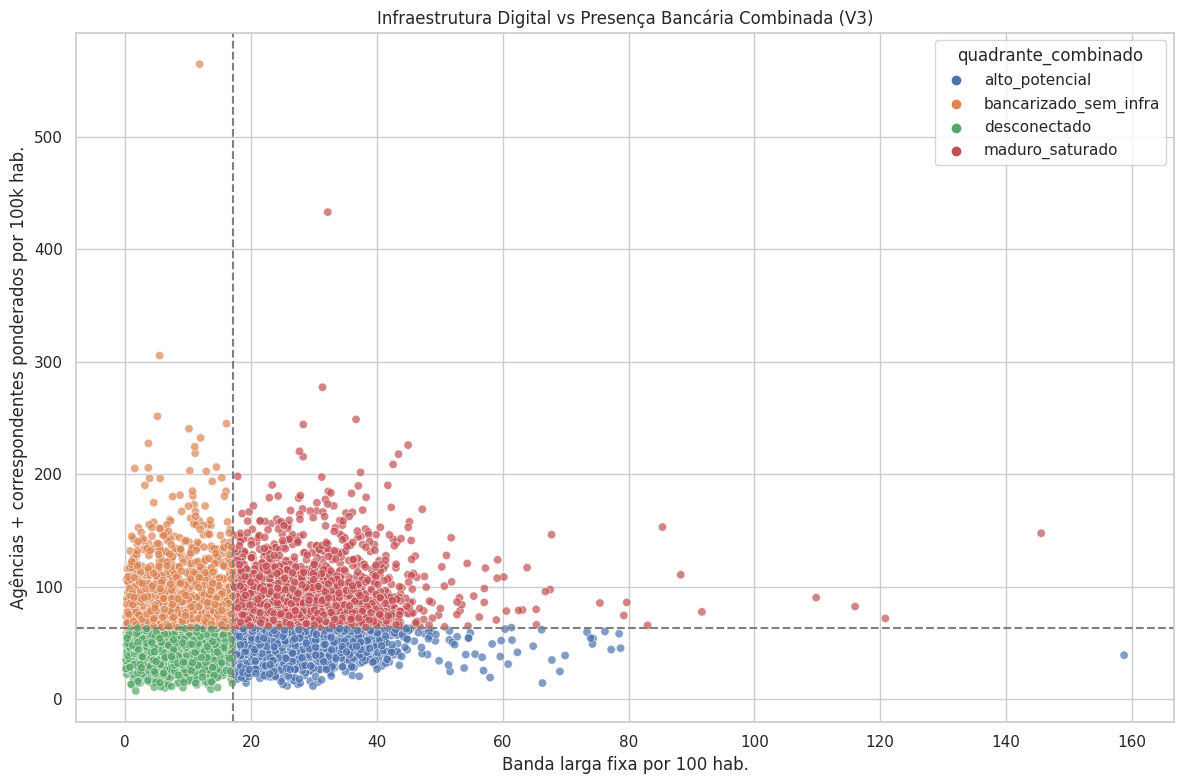

In [9]:
# Quadrantes com presença combinada da V3 (agências + correspondentes ponderados)
df_v3 = pd.read_parquet(
    PROCESSED_DATA_DIR / "analytics_ipb_v3_presenca_completa.parquet"
)

df_q = df[
    [
        "id_municipio",
        "nome_municipio",
        "sigla_uf",
        "banda_larga_fixa_por_100_hab",
        "agencias_por_100k_hab",
    ]
].merge(
    df_v3[["id_municipio", "correspondentes_ponderados_por_100k_hab"]],
    on="id_municipio",
    how="left",
)
df_q["presenca_combinada"] = df_q["agencias_por_100k_hab"].fillna(0) + df_q[
    "correspondentes_ponderados_por_100k_hab"
].fillna(0)

mediana_presenca = df_q["presenca_combinada"].median()


def classificar_quadrante(banda, presenca):
    if banda >= mediana_banda and presenca >= mediana_presenca:
        return "maduro_saturado"
    if banda >= mediana_banda and presenca < mediana_presenca:
        return "alto_potencial"
    if banda < mediana_banda and presenca >= mediana_presenca:
        return "bancarizado_sem_infra"
    return "desconectado"


df_q["quadrante_combinado"] = [
    classificar_quadrante(b, p)
    for b, p in zip(
        df_q["banda_larga_fixa_por_100_hab"], df_q["presenca_combinada"]
    )
]

quadrantes_novo = df_q["quadrante_combinado"].value_counts()
logger.info("Quadrantes com presença combinada:\n%s", quadrantes_novo)

cruzamento = pd.crosstab(df["quadrante"], df_q["quadrante_combinado"])
display(cruzamento)

n_maduros_antigo = int((df["quadrante"] == "maduro_saturado").sum())
n_maduros_permanecem = int(
    ((df["quadrante"] == "maduro_saturado")
     & (df_q["quadrante_combinado"] == "maduro_saturado")).sum()
)
logger.info(
    "Maduros saturados (só agências): %d; permanecem saturados com presença "
    "combinada: %d (%.1f%%)",
    n_maduros_antigo,
    n_maduros_permanecem,
    n_maduros_permanecem / n_maduros_antigo * 100,
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=df_q,
    x="banda_larga_fixa_por_100_hab",
    y="presenca_combinada",
    hue="quadrante_combinado",
    alpha=0.7,
    ax=ax,
)
ax.axvline(mediana_banda, color="gray", linestyle="--")
ax.axhline(mediana_presenca, color="gray", linestyle="--")
ax.set_title("Infraestrutura Digital vs Presença Bancária Combinada (V3)")
ax.set_xlabel("Banda larga fixa por 100 hab.")
ax.set_ylabel("Agências + correspondentes ponderados por 100k hab.")
plt.tight_layout()
save_figure(fig, "03_quadrantes_presenca_combinada.png")
plt.show()

## 6. Top estados com maior % de municípios sem agência

2026-09-03 12:13:46,105 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/03_pct_sem_agencia_uf.png


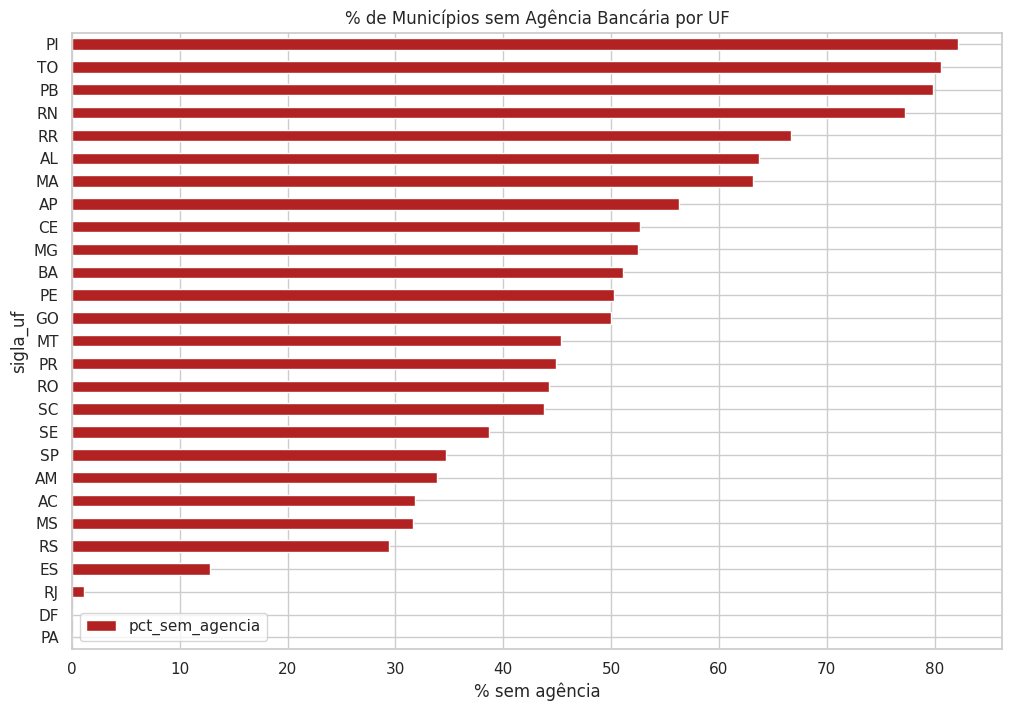

In [10]:
uf_sem_agencia = (
    df.groupby("sigla_uf")
    .agg(total=("id_municipio", "count"), sem_agencia=("flag_sem_agencia", "sum"))
    .reset_index()
)
uf_sem_agencia["pct_sem_agencia"] = (
    uf_sem_agencia["sem_agencia"] / uf_sem_agencia["total"] * 100
)
uf_sem_agencia = uf_sem_agencia.sort_values("pct_sem_agencia", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
uf_sem_agencia.plot(
    x="sigla_uf", y="pct_sem_agencia", kind="barh", ax=ax, color="firebrick"
)
ax.set_title("% de Municípios sem Agência Bancária por UF")
ax.set_xlabel("% sem agência")
save_figure(fig, "03_pct_sem_agencia_uf.png")
plt.show()

In [11]:
report = {
    "municipios_sem_agencia": int(sem_agencia),
    "pct_municipios_sem_agencia": round(sem_agencia / len(df) * 100, 2),
    "distribuicao_quadrantes": df["quadrante"].value_counts().to_dict(),
    "distribuicao_quadrantes_presenca_combinada": quadrantes_novo.to_dict(),
    "cruzamento_quadrantes_antigo_x_combinado": cruzamento.to_dict(),
    "maduros_saturados_sobrevivem": n_maduros_permanecem,
    "correspondentes_total": int(len(df_corr)),
    "correspondentes_tipo_pct": (
        df_corr["Tipo"].value_counts(normalize=True) * 100
    ).round(1).to_dict(),
    "top_uf_sem_agencia": uf_sem_agencia.tail(5).to_dict(orient="records"),
}
save_json(report, "03_infra_gap_bancario.json")

2026-09-03 12:13:47,296 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/03_infra_gap_bancario.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/03_infra_gap_bancario.json')

## Resumo Executivo

Este notebook gerou o relatório `03_infra_gap_bancario.json`. Abaixo segue um resumo legível dos principais resultados.

In [12]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path.cwd().parents[1] / "data/processed/reports/03_infra_gap_bancario.json"
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")

{
  "municipios_sem_agencia": 2656,
  "pct_municipios_sem_agencia": 47.68,
  "distribuicao_quadrantes": {
    "maduro_saturado": 1735,
    "desconectado": 1735,
    "bancarizado_sem_infra": 1050,
    "alto_potencial": 1050
  },
  "distribuicao_quadrantes_presenca_combinada": {
    "desconectado": 1552,
    "maduro_saturado": 1552,
    "alto_potencial": 1233,
    "bancarizado_sem_infra": 1233
  },
  "cruzamento_quadrantes_antigo_x_combinado": {
    "alto_potencial": {
      "alto_potencial": 513,
      "bancarizado_sem_infra": 0,
      "desconectado": 0,
      "maduro_saturado": 720
    },
    "bancarizado_sem_infra": {
      "alto_potencial": 0,
      "bancarizado_sem_infra": 430,
      "desconectado": 803,
      "maduro_saturado": 0
    },
    "desconectado": {
      "alto_potencial": 0,
      "bancarizado_sem_infra": 620,
      "desconectado": 932,
      "maduro_saturado": 0
    },
    "maduro_saturado": {
      "alto_potencial": 537,
      "bancarizado_sem_infra": 0,
      "desconec